## [QDA (Análise Discriminante Quadrática)](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html)

Colab de referência: https://colab.research.google.com/drive/1KyyJUAWqp15cqjTF_YQeSdCHZTPA04ic

Características:
* Também é um algoritmo de classificação;
* Diferentemente do LDA, não supõe que as variâncias das classes são iguais;
* No LDA (as classes compartilham a mesma matriz de covariância onde é possível traçar limiares de decisões lineares);
* No QDA, cada **classe** possui **sua matriz de covariância**, resultando em resultados de decisões quadráticas;
* **QDA é mais adequado para**: **(1)** problemas onde as fronteiras de decisão entre as classes são não-lineares, e **(2)** **classes** tem distribuições com **diferentes variâncias**;
* QDA é mais flexível que LDA;
* Permite adaptação mais precisa. No entanto, pode aumentar o risco de *overfitting* em casos de conjunto de dados muito pequenos ou com muitas dimensões;

In [1]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# carregar o dataset
iris = load_iris(as_frame=True)
df = iris.frame

# df.head()

# separar em X os dados com todas as características
X = df.iloc[:, :-1].values

# separar em Y os dados a classificação das espécies
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Cria e treina o modelo QDA

In [2]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


#### Teste (obter predição a partir do modelo treinado)

In [3]:
y_pred_qda_train = qda.predict(X_train)
y_pred_qda_test = qda.predict(X_test)

#### Desempenho (acurácia)

In [4]:
qda_train_acuracia = accuracy_score(y_train, y_pred_qda_train)
qda_train_acuracia = qda_train_acuracia * 100
print(f"Acurácia no treino: {qda_train_acuracia:.2f}%")

qda_test_acuracia = accuracy_score(y_test, y_pred_qda_test)
qda_test_acuracia = qda_test_acuracia * 100
print(f"Acurácia no teste: {qda_test_acuracia:.2f}%")


Acurácia no treino: 98.10%
Acurácia no teste: 100.00%


#### Como descobrir onde o modelo errou?

<Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>

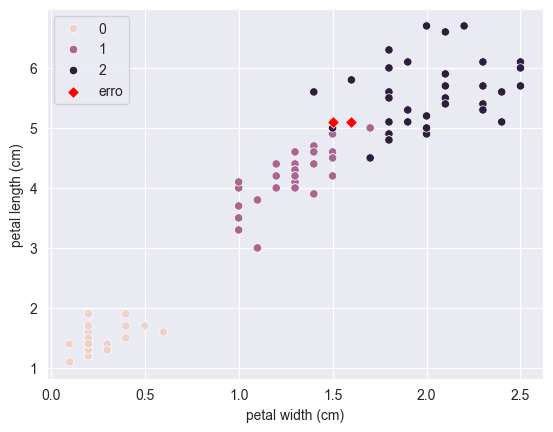

In [5]:
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns


# 1 - criar dataframe para melhor visualização
iris = load_iris(as_frame=True)

# item 'frame' permite o acesso ao dataframe
df = iris.frame

# pegando os rótulos
target_names = iris.target_names

# print(target_names)

# adicionando os nomes dos rótulos em uma nova coluna
df['species'] = target_names[df['target']]

df.head()

#  retirando as duas últimas colunas (target e species)
df_qda_train = pd.DataFrame(X_train, columns=df.iloc[:, :-2].columns)

# adicionar o treinamento na coluna espécies
df_qda_train['species']=y_train

# adicionar ao df as espécies preditas
df_qda_train['species_predicted'] = y_pred_qda_train

df_qda_train.head()

# df.info()

# identificando os erros
df_qda_train_erros = df_qda_train.query("species != species_predicted")

df_qda_train_erros.head()

# plotando o gráfico com realce nos erros
sns.scatterplot(df_qda_train.sort_values(by='species'),
                x='petal width (cm)',
                y='petal length (cm)',
                hue='species')

sns.scatterplot(df_qda_train_erros.sort_values(by='species'),
                x='petal width (cm)',
                y='petal length (cm)',
                color = 'r',
                marker='D',
                label= 'erro')